In [1]:
from importlib.metadata import version
import nltk
from nltk.corpus import stopwords
from bs4 import BeautifulSoup 
import tensorflow
import summa
import numpy as np
import pandas as pd
import os
import re

nltk.download('stopwords')

print(nltk.__version__)
print(tensorflow.__version__)
print(pd.__version__)
print(version('summa'))

3.6.5
2.6.0
1.3.3
1.2.0


[nltk_data] Downloading package stopwords to /aiffel/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/sunnysai12345/News_Summary/master/news_summary_more.csv", filename="news_summary_more.csv")
data = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')

In [3]:
data.sample(10)

,headlines,text
33842,"Kanye slams Obama, calls US President Trump hi...",Slamming former US President Barack Obama for ...
39181,Threat to PM can't be taken lightly as Cong in...,After the police said some CPI (Maoists) membe...
67570,Dancer Shantanu Maheshwari wins Khatron Ke Khi...,Actor-dancer Shantanu Maheshwari has won the e...
19889,Diesel price hits record high of Ã¢ÂÂ¹69.46 p...,Diesel prices on Monday hit a record high of Ã...
94337,Burnt body of man with tied hands found in Gor...,A man has been allegedly burnt alive in Uttar ...
27534,"Trump misspells 'pore' as 'pour', gets trolled...",Harry Potter series author JK Rowling posted a...
1641,TN woman who was transfused with HIV-infected ...,Weeks after a pregnant woman in Tamil Nadu was...
27922,Man kills daughter for talking to boyfriend de...,A man in Andhra Pradesh's Thotaravulapadu alle...
50769,TN driver burns self after cops assault him ov...,A 21-year-old taxi driver from Tamil Nadu's Ch...
24081,Over 60 Ghaziabad flats evacuated after road c...,Residents of over 60 flats from two Ghaziabad ...


In [4]:
print('전체 샘플수 :', (len(data)))

전체 샘플수 : 98401


In [5]:
data = data[['text', 'headlines']]

#랜덤한 15개 샘플 출력
data.sample(15)

,text,headlines
3204,Vidarbha's 40-year-old batsman Wasim Jaffer on...,40-yr-old Wasim Jaffer becomes Ranji Trophy's ...
6609,"A lightsaber, said to have been used by the 'S...",Star Wars lightsaber taken off auction over au...
93481,Actress Karisma Kapoor has shared an old pictu...,Karisma shares pic from 1997 film Dil To Pagal...
28376,An eight-year-old girl was allegedly abducted ...,8-year-old girl abducted and raped in Madhya P...
32146,Iranian President Hassan Rouhani has hinted Ir...,Iran Prez hints at staying in nuclear deal aft...
33904,Before Asaram's conviction in a minor's rape c...,Which self-styled godmen have been accused of ...
89387,Samajwadi Party patriarch Mulayam Singh Yadav ...,Why hasn't Akhilesh returned SP chief's post t...
78399,The Ministry of Women and Child Development (W...,"Mother should be natural guardian, not father:..."
15487,A new song titled 'Kem Cho' from Saif Ali Khan...,'Kem Cho' song from Saif Ali Khan's 'Baazaar' ...
84517,The first teaser of actor Shah Rukh Khan and A...,"1st teaser of SRK, Anushka's 'Jab Harry Met Se..."


In [6]:
print('text 열에서 중복을 배제한 유일한 샘플의 수 :', data['text'].nunique())
print('headlines 열에서 중복을 배제한 유일한 샘플의 수 :', data['headlines'].nunique())

text 열에서 중복을 배제한 유일한 샘플의 수 : 98360
headlines 열에서 중복을 배제한 유일한 샘플의 수 : 98280


In [7]:
# inplace=True 를 설정하면 DataFrame 타입 값을 return 하지 않고 data 내부를 직접적으로 바꿉니다
data.drop_duplicates(subset = ['text'], inplace=True)
print('전체 샘플수 :', (len(data)))

전체 샘플수 : 98360


In [8]:
# dataframe에 null값이 있는지 확인

print(data.isnull().sum())

text         0
headlines    0
dtype: int64


In [9]:
# null값이 하나도 없음을 알 수 있었다.

In [10]:
# 아래의 URL에서 정규화 사전을 인용
# https://stackoverflow.com/questions/19790188/expanding-english-language-contractions-in-python

contractions = {"ain't": "is not", "aren't": "are not","can't": "cannot", "'cause": "because", "could've": "could have", "couldn't": "could not",
                           "didn't": "did not",  "doesn't": "does not", "don't": "do not", "hadn't": "had not", "hasn't": "has not", "haven't": "have not",
                           "he'd": "he would","he'll": "he will", "he's": "he is", "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is",
                           "I'd": "I would", "I'd've": "I would have", "I'll": "I will", "I'll've": "I will have","I'm": "I am", "I've": "I have", "i'd": "i would",
                           "i'd've": "i would have", "i'll": "i will",  "i'll've": "i will have","i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would",
                           "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have","it's": "it is", "let's": "let us", "ma'am": "madam",
                           "mayn't": "may not", "might've": "might have","mightn't": "might not","mightn't've": "might not have", "must've": "must have",
                           "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have","o'clock": "of the clock",
                           "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not", "sha'n't": "shall not", "shan't've": "shall not have",
                           "she'd": "she would", "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have", "she's": "she is",
                           "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have", "so've": "so have","so's": "so as",
                           "this's": "this is","that'd": "that would", "that'd've": "that would have", "that's": "that is", "there'd": "there would",
                           "there'd've": "there would have", "there's": "there is", "here's": "here is","they'd": "they would", "they'd've": "they would have",
                           "they'll": "they will", "they'll've": "they will have", "they're": "they are", "they've": "they have", "to've": "to have",
                           "wasn't": "was not", "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have", "we're": "we are",
                           "we've": "we have", "weren't": "were not", "what'll": "what will", "what'll've": "what will have", "what're": "what are",
                           "what's": "what is", "what've": "what have", "when's": "when is", "when've": "when have", "where'd": "where did", "where's": "where is",
                           "where've": "where have", "who'll": "who will", "who'll've": "who will have", "who's": "who is", "who've": "who have",
                           "why's": "why is", "why've": "why have", "will've": "will have", "won't": "will not", "won't've": "will not have",
                           "would've": "would have", "wouldn't": "would not", "wouldn't've": "would not have", "y'all": "you all",
                           "y'all'd": "you all would","y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have",
                           "you'd": "you would", "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have",
                           "you're": "you are", "you've": "you have"}

print("정규화 사전의 수: ", len(contractions))

정규화 사전의 수:  120


In [11]:
# NLTK에서 불용어 사전을 인용

print('불용어 개수 :', len(stopwords.words('english') ))
print(stopwords.words('english'))

불용어 개수 : 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "

In [12]:
# 데이터 전처리 함수

def preprocess_sentence(sentence, remove_stopwords=True):
    sentence = sentence.lower() # 텍스트 소문자화
    sentence = BeautifulSoup(sentence, "lxml").text # <br />, <a href = ...> 등의 html 태그 제거
    sentence = re.sub(r'\([^)]*\)', '', sentence) # 괄호로 닫힌 문자열 (...) 제거 Ex) my husband (and myself!) for => my husband for
    sentence = re.sub('"','', sentence) # 쌍따옴표 " 제거
    sentence = ' '.join([contractions[t] if t in contractions else t for t in sentence.split(" ")]) # 약어 정규화
    sentence = re.sub(r"'s\b","", sentence) # 소유격 제거. Ex) roland's -> roland
    sentence = re.sub("[^a-zA-Z]", " ", sentence) # 영어 외 문자(숫자, 특수문자 등) 공백으로 변환
    sentence = re.sub('[m]{2,}', 'mm', sentence) # m이 3개 이상이면 2개로 변경. Ex) ummmmmmm yeah -> umm yeah
    
    # 불용어 제거 (Text)
    if remove_stopwords:
        tokens = ' '.join(word for word in sentence.split() if not word in stopwords.words('english') if len(word) > 1)
    # 불용어 미제거 (Summary)
    else:
        tokens = ' '.join(word for word in sentence.split() if len(word) > 1)
    return tokens

In [13]:
# 데이터 전처리 함수 시험

temp_text = 'Everything I bought was great, infact I ordered twice and the third ordered was<br />for my mother and father.'
temp_headlines = 'Great way to start (or finish) the day!!!'

print("text: ", preprocess_sentence(temp_text))
print("headlines:", preprocess_sentence(temp_headlines, False))

text:  everything bought great infact ordered twice third ordered wasfor mother father
headlines: great way to start the day


In [14]:
# 전체 text 데이터에 대한 전처리 : 10분 이상 시간이 걸릴 수 있습니다. 
# 매번 이 작업을 새로 실행하려면 시간이 너무 오래 걸리므로
# 전처리 작업의 결과를 json으로 담아서 그 json 파일이 없을 때만 전처리를 수행하는 코드를 작성.

import json
import os

clean_text = []
clean_text_path = "clean_text.json"

if not os.path.isfile(clean_text_path):
    for text in data['text']:
        cleaned_texts = preprocess_sentence(text)
        clean_text.append(cleaned_texts)
    with open(clean_text_path, 'w') as f:
        json.dump(clean_text, f)
else:
    with open(clean_text_path, 'r') as f:
        clean_text = json.load(f)

# 전처리 후 출력
print("text 전처리 후 결과: ", clean_text[:5])

text 전처리 후 결과:  ['saurav kant alumnus upgrad iiit pg program machine learning artificial intelligence sr systems engineer infosys almost years work experience program upgrad degree career support helped transition data scientist tech mahindra salary hike upgrad online power learning powered lakh careers', 'kunal shah credit card bill payment platform cred gave users chance win free food swiggy one year pranav kaushik delhi techie bagged reward spending cred coins users get one cred coin per rupee bill paid used avail rewards brands like ixigo bookmyshow ubereats cult fit', 'new zealand defeated india wickets fourth odi hamilton thursday win first match five match odi series india lost international match rohit sharma captaincy consecutive victories dating back march match witnessed india getting seventh lowest total odi cricket history', 'aegon life iterm insurance plan customers enjoy tax benefits premiums paid save taxes plan provides life cover age years also customers options insur

In [15]:
# 전체 headlines 데이터에 대한 전처리 : 5분 이상 시간이 걸릴 수 있습니다. 
# 매번 이 작업을 새로 실행하려면 시간이 너무 오래 걸리므로
# 전처리 작업의 결과를 json으로 담아서 그 json 파일이 없을 때만 전처리를 수행하는 코드를 작성.

import json
import os

clean_headlines = []
clean_headlines_path = "clean_headlines.json"

if not os.path.isfile(clean_headlines_path):
    for text in data['headlines']:
        cleaned_headlines = preprocess_sentence(text, remove_stopwords=False)
        clean_headlines.append(cleaned_headlines)
    with open(clean_headlines_path, 'w') as f:
        json.dump(clean_headlines, f)
else:
    with open(clean_headlines_path, 'r') as f:
        clean_headlines = json.load(f)

print("headlines 전처리 후 결과: ", clean_headlines[:5])

headlines 전처리 후 결과:  ['upgrad learner switches to career in ml al with salary hike', 'delhi techie wins free food from swiggy for one year on cred', 'new zealand end rohit sharma led india match winning streak', 'aegon life iterm insurance plan helps customers save tax', 'have known hirani for yrs what if metoo claims are not true sonam']


In [16]:
data2 = pd.DataFrame({'text' : clean_text, 'headlines' : clean_headlines})
data2['text'] = clean_text
data2['headlines'] = clean_headlines

# 빈 값을 Null 값으로 변환
data2.replace('', np.nan, inplace=True)

In [17]:
data2.isnull().sum()

text         0
headlines    0
dtype: int64

In [18]:
# 이번에도 null값이 하나도 없음을 알 수 있었다.

텍스트의 최소 길이 : 1
텍스트의 최대 길이 : 60
텍스트의 평균 길이 : 35.09968483123221
헤드라인의 최소 길이 : 1
헤드라인의 최대 길이 : 16
헤드라인의 평균 길이 : 9.299532330215534


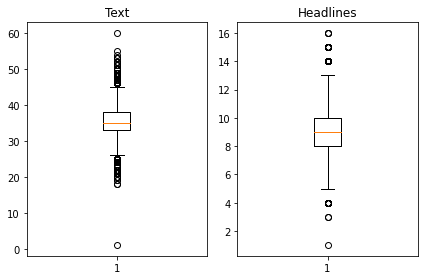

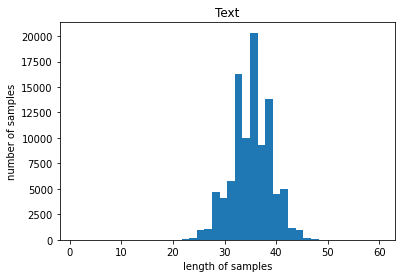

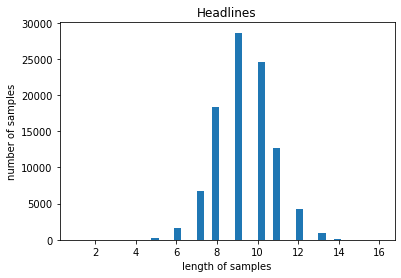

In [19]:
# 길이 분포 출력
import matplotlib.pyplot as plt

text_len = [len(s.split()) for s in data2['text']]
headlines_len = [len(s.split()) for s in data2['headlines']]

print('텍스트의 최소 길이 : {}'.format(np.min(text_len)))
print('텍스트의 최대 길이 : {}'.format(np.max(text_len)))
print('텍스트의 평균 길이 : {}'.format(np.mean(text_len)))
print('헤드라인의 최소 길이 : {}'.format(np.min(headlines_len)))
print('헤드라인의 최대 길이 : {}'.format(np.max(headlines_len)))
print('헤드라인의 평균 길이 : {}'.format(np.mean(headlines_len)))

plt.subplot(1,2,1)
plt.boxplot(text_len)
plt.title('Text')
plt.subplot(1,2,2)
plt.boxplot(headlines_len)
plt.title('Headlines')
plt.tight_layout()
plt.show()

plt.title('Text')
plt.hist(text_len, bins = 40)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

plt.title('Headlines')
plt.hist(headlines_len, bins = 40)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

In [20]:
text_max_len = 38
headlines_max_len = 10

In [21]:
def below_threshold_len(max_len, nested_list):
  cnt = 0
  for s in nested_list:
    if(len(s.split()) <= max_len):
        cnt = cnt + 1
  print('전체 샘플 중 길이가 %s 이하인 샘플의 비율: %s'%(max_len, (cnt / len(nested_list))))

In [22]:
below_threshold_len(text_max_len, data2['text'])
below_threshold_len(headlines_max_len,  data2['headlines'])
print('전체 샘플수 :', (len(data2)))

전체 샘플 중 길이가 38 이하인 샘플의 비율: 0.8163379422529483
전체 샘플 중 길이가 10 이하인 샘플의 비율: 0.8162972753151687
전체 샘플수 : 98360


In [23]:
data2 = data2[data2['text'].apply(lambda x: len(x.split()) <= text_max_len) & 
            data2['headlines'].apply(lambda x: len(x.split()) <= headlines_max_len)]

print('전체 샘플수 :', (len(data2)))

전체 샘플수 : 65295


In [24]:
# 요약 데이터에는 시작 토큰과 종료 토큰을 추가한다.
data2['decoder_input'] = data2['headlines'].apply(lambda x : 'sostoken '+ x)
data2['decoder_target'] = data2['headlines'].apply(lambda x : x + ' eostoken')
data2.head()

,text,headlines,decoder_input,decoder_target
2,new zealand defeated india wickets fourth odi ...,new zealand end rohit sharma led india match w...,sostoken new zealand end rohit sharma led indi...,new zealand end rohit sharma led india match w...
3,aegon life iterm insurance plan customers enjo...,aegon life iterm insurance plan helps customer...,sostoken aegon life iterm insurance plan helps...,aegon life iterm insurance plan helps customer...
5,pakistani singer rahat fateh ali khan denied r...,rahat fateh ali khan denies getting notice for...,sostoken rahat fateh ali khan denies getting n...,rahat fateh ali khan denies getting notice for...
9,congress candidate shafia zubair ramgarh assem...,cong wins ramgarh bypoll in rajasthan takes to...,sostoken cong wins ramgarh bypoll in rajasthan...,cong wins ramgarh bypoll in rajasthan takes to...
10,two minor cousins uttar pradesh gorakhpur alle...,up cousins fed human excreta for friendship wi...,sostoken up cousins fed human excreta for frie...,up cousins fed human excreta for friendship wi...


In [25]:
encoder_input = np.array(data2['text']) # 인코더의 입력
decoder_input = np.array(data2['decoder_input']) # 디코더의 입력
decoder_target = np.array(data2['decoder_target']) # 디코더의 레이블

In [26]:
indices = np.arange(encoder_input.shape[0])
np.random.shuffle(indices)
print(indices)

[ 3457 17198 43217 ... 53788  6129 19022]


In [27]:
encoder_input = encoder_input[indices]
decoder_input = decoder_input[indices]
decoder_target = decoder_target[indices]

In [28]:
n_of_val = int(len(encoder_input)*0.2)
print('테스트 데이터의 수 :', n_of_val)

테스트 데이터의 수 : 13059


In [29]:
encoder_input_train = encoder_input[:-n_of_val]
decoder_input_train = decoder_input[:-n_of_val]
decoder_target_train = decoder_target[:-n_of_val]

encoder_input_test = encoder_input[-n_of_val:]
decoder_input_test = decoder_input[-n_of_val:]
decoder_target_test = decoder_target[-n_of_val:]

print('훈련 데이터의 개수 :', len(encoder_input_train))
print('훈련 레이블의 개수 :', len(decoder_input_train))
print('테스트 데이터의 개수 :', len(encoder_input_test))
print('테스트 레이블의 개수 :', len(decoder_input_test))

훈련 데이터의 개수 : 52236
훈련 레이블의 개수 : 52236
테스트 데이터의 개수 : 13059
테스트 레이블의 개수 : 13059


In [30]:
# 단어 집합(vocabulary) 만들기 및 정수 인코딩

from tensorflow.keras.preprocessing.text import Tokenizer 

src_tokenizer = Tokenizer() # 토크나이저 정의
src_tokenizer.fit_on_texts(encoder_input_train) # 입력된 데이터로부터 단어 집합 생성

In [31]:
threshold = 6
total_cnt = len(src_tokenizer.word_index) # 단어의 수
rare_cnt = 0 # 등장 빈도수가 threshold보다 작은 단어의 개수를 카운트
total_freq = 0 # 훈련 데이터의 전체 단어 빈도수 총 합
rare_freq = 0 # 등장 빈도수가 threshold보다 작은 단어의 등장 빈도수의 총 합

# 단어와 빈도수의 쌍(pair)을 key와 value로 받는다.
for key, value in src_tokenizer.word_counts.items():
    total_freq = total_freq + value

    # 단어의 등장 빈도수가 threshold보다 작으면
    if(value < threshold):
        rare_cnt = rare_cnt + 1
        rare_freq = rare_freq + value

print('단어 집합(vocabulary)의 크기 :', total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s'%(threshold - 1, rare_cnt))
print('단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 %s'%(total_cnt - rare_cnt))
print("단어 집합에서 희귀 단어의 비율:", (rare_cnt / total_cnt)*100)
print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율:", (rare_freq / total_freq)*100)

단어 집합(vocabulary)의 크기 : 57217
등장 빈도가 5번 이하인 희귀 단어의 수: 37794
단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 19423
단어 집합에서 희귀 단어의 비율: 66.05379520072707
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 3.995650608677792


In [32]:
src_vocab = 20000
src_tokenizer = Tokenizer(num_words=src_vocab) # 단어 집합의 크기를 20,000으로 제한
src_tokenizer.fit_on_texts(encoder_input_train) # 단어 집합 재생성

In [33]:
# 텍스트 시퀀스를 정수 시퀀스로 변환
encoder_input_train = src_tokenizer.texts_to_sequences(encoder_input_train) 
encoder_input_test = src_tokenizer.texts_to_sequences(encoder_input_test)

# 잘 진행되었는지 샘플 출력
print(encoder_input_train[:3])

[[4793, 43, 65, 18, 6085, 6939, 50, 1, 418, 501, 349, 1121, 2203, 45, 409, 446, 660, 430, 168, 1498, 232, 42, 45, 289, 257, 168, 29, 256, 346, 6, 1, 8, 1647, 349, 1509], [35, 13, 133, 630, 125, 901, 688, 401, 3192, 2059, 74, 979, 3791, 2818, 135, 1002, 8667, 6426, 215, 497, 318, 3193, 1002, 2494, 1763, 2140, 1844, 4682, 1902, 2523, 1002, 624, 935, 1169, 2059, 157, 101], [3346, 29, 30, 1371, 2398, 1304, 3651, 3043, 74, 215, 277, 9401, 17877, 324, 279, 1049, 3651, 663, 364, 896, 1697, 101, 2598, 2860, 277, 13859, 14681, 279, 3651, 6940, 2297, 12, 114, 663]]


In [34]:
tar_tokenizer = Tokenizer()
tar_tokenizer.fit_on_texts(decoder_input_train)

In [35]:
threshold = 3
total_cnt = len(tar_tokenizer.word_index) # 단어의 수
rare_cnt = 0 # 등장 빈도수가 threshold보다 작은 단어의 개수를 카운트
total_freq = 0 # 훈련 데이터의 전체 단어 빈도수 총 합
rare_freq = 0 # 등장 빈도수가 threshold보다 작은 단어의 등장 빈도수의 총 합

# 단어와 빈도수의 쌍(pair)을 key와 value로 받는다.
for key, value in tar_tokenizer.word_counts.items():
    total_freq = total_freq + value

    # 단어의 등장 빈도수가 threshold보다 작으면
    if(value < threshold):
        rare_cnt = rare_cnt + 1
        rare_freq = rare_freq + value

print('단어 집합(vocabulary)의 크기 :', total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s'%(threshold - 1, rare_cnt))
print('단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 %s'%(total_cnt - rare_cnt))
print("단어 집합에서 희귀 단어의 비율:", (rare_cnt / total_cnt)*100)
print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율:", (rare_freq / total_freq)*100)

단어 집합(vocabulary)의 크기 : 25829
등장 빈도가 2번 이하인 희귀 단어의 수: 12978
단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 12851
단어 집합에서 희귀 단어의 비율: 50.24584769058036
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 3.2128341912581293


In [36]:
tar_vocab = 13000
tar_tokenizer = Tokenizer(num_words=tar_vocab) 
tar_tokenizer.fit_on_texts(decoder_input_train)
tar_tokenizer.fit_on_texts(decoder_target_train)

# 텍스트 시퀀스를 정수 시퀀스로 변환
decoder_input_train = tar_tokenizer.texts_to_sequences(decoder_input_train) 
decoder_target_train = tar_tokenizer.texts_to_sequences(decoder_target_train)
decoder_input_test = tar_tokenizer.texts_to_sequences(decoder_input_test)
decoder_target_test = tar_tokenizer.texts_to_sequences(decoder_target_test)

# 잘 변환되었는지 확인
print('input')
print('input ',decoder_input_train[:5])
print('target')
print('decoder ',decoder_target_train[:5])

input
input  [[1, 396, 352, 509, 97, 15, 3472, 36, 4, 229, 3902], [1, 9431, 6948, 269, 380, 3473, 43, 2533, 6, 241], [1, 1745, 425, 294, 629, 269, 185, 12853], [1, 30, 1669, 93, 198, 4983, 1265, 5, 3023], [1, 3612, 155, 158, 751]]
target
decoder  [[396, 352, 509, 97, 15, 3472, 36, 4, 229, 3902, 2], [9431, 6948, 269, 380, 3473, 43, 2533, 6, 241, 2], [1745, 425, 294, 629, 269, 185, 12853, 2], [30, 1669, 93, 198, 4983, 1265, 5, 3023, 2], [3612, 155, 158, 751, 2]]


In [37]:
drop_train = [index for index, sentence in enumerate(decoder_input_train) if len(sentence) == 1]
drop_test = [index for index, sentence in enumerate(decoder_input_test) if len(sentence) == 1]

print('삭제할 훈련 데이터의 개수 :', len(drop_train))
print('삭제할 테스트 데이터의 개수 :', len(drop_test))

encoder_input_train = [sentence for index, sentence in enumerate(encoder_input_train) if index not in drop_train]
decoder_input_train = [sentence for index, sentence in enumerate(decoder_input_train) if index not in drop_train]
decoder_target_train = [sentence for index, sentence in enumerate(decoder_target_train) if index not in drop_train]

encoder_input_test = [sentence for index, sentence in enumerate(encoder_input_test) if index not in drop_test]
decoder_input_test = [sentence for index, sentence in enumerate(decoder_input_test) if index not in drop_test]
decoder_target_test = [sentence for index, sentence in enumerate(decoder_target_test) if index not in drop_test]

print('훈련 데이터의 개수 :', len(encoder_input_train))
print('훈련 레이블의 개수 :', len(decoder_input_train))
print('테스트 데이터의 개수 :', len(encoder_input_test))
print('테스트 레이블의 개수 :', len(decoder_input_test))

삭제할 훈련 데이터의 개수 : 0
삭제할 테스트 데이터의 개수 : 0
훈련 데이터의 개수 : 52236
훈련 레이블의 개수 : 52236
테스트 데이터의 개수 : 13059
테스트 레이블의 개수 : 13059


In [38]:
# 패딩하기

from tensorflow.keras.preprocessing.sequence import pad_sequences

encoder_input_train = pad_sequences(encoder_input_train, maxlen=text_max_len, padding='post')
encoder_input_test = pad_sequences(encoder_input_test, maxlen=text_max_len, padding='post')
decoder_input_train = pad_sequences(decoder_input_train, maxlen=headlines_max_len, padding='post')
decoder_target_train = pad_sequences(decoder_target_train, maxlen=headlines_max_len, padding='post')
decoder_input_test = pad_sequences(decoder_input_test, maxlen=headlines_max_len, padding='post')
decoder_target_test = pad_sequences(decoder_target_test, maxlen=headlines_max_len, padding='post')

In [39]:
# LSTM 인코더 설계

from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Concatenate, TimeDistributed
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


# 인코더 설계 시작
embedding_dim = 128
hidden_size = 256

# 인코더
encoder_inputs = Input(shape=(text_max_len,))

# 인코더의 임베딩 층
enc_emb = Embedding(src_vocab, embedding_dim)(encoder_inputs)

# 인코더의 LSTM 1
# encoder_lstm1 = LSTM(hidden_size, return_sequences=True, return_state=True ,dropout = 0.4, recurrent_dropout = 0.4)
encoder_lstm1 = LSTM(hidden_size, return_sequences=True, return_state=True ,dropout = 0.4)
encoder_output1, state_h1, state_c1 = encoder_lstm1(enc_emb)

# 인코더의 LSTM 2
encoder_lstm2 = LSTM(hidden_size, return_sequences=True, return_state=True ,dropout = 0.4)
encoder_output2, state_h2, state_c2 = encoder_lstm2(encoder_output1, initial_state=[state_h1, state_c1])

# 인코더의 LSTM 3
encoder_lstm3 = LSTM(hidden_size, return_sequences=True, return_state=True ,dropout = 0.4)
encoder_outputs, state_h, state_c = encoder_lstm3(encoder_output2, initial_state=[state_h2, state_c2])

In [40]:
# 디코더 설계
decoder_inputs = Input(shape=(None,))

# 디코더의 임베딩 층
dec_emb_layer = Embedding(tar_vocab, embedding_dim)
dec_emb = dec_emb_layer(decoder_inputs)

# 디코더의 LSTM
# decoder_lstm = LSTM(hidden_size, return_sequences=True, return_state=True, dropout=0.4, recurrent_dropout=0.2)
decoder_lstm = LSTM(hidden_size, return_sequences=True, return_state=True, dropout=0.4)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=[state_h, state_c])

In [41]:
# 디코더의 출력층
decoder_softmax_layer = Dense(tar_vocab, activation='softmax')
decoder_softmax_outputs = decoder_softmax_layer(decoder_outputs) 

# 모델 정의
model = Model([encoder_inputs, decoder_inputs], decoder_softmax_outputs)
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 38)]         0                                            
__________________________________________________________________________________________________
embedding (Embedding)           (None, 38, 128)      2560000     input_1[0][0]                    
__________________________________________________________________________________________________
lstm (LSTM)                     [(None, 38, 256), (N 394240      embedding[0][0]                  
__________________________________________________________________________________________________
input_2 (InputLayer)            [(None, None)]       0                                            
______________________________________________________________________________________________

In [42]:
from tensorflow.keras.layers import AdditiveAttention

# 어텐션 층(어텐션 함수)
attn_layer = AdditiveAttention(name='attention_layer')

# 인코더와 디코더의 모든 time step의 hidden state를 어텐션 층에 전달하고 결과를 리턴
attn_out = attn_layer([decoder_outputs, encoder_outputs])


# 어텐션의 결과와 디코더의 hidden state들을 연결
decoder_concat_input = Concatenate(axis=-1, name='concat_layer')([decoder_outputs, attn_out])

# 디코더의 출력층
decoder_softmax_layer = Dense(tar_vocab, activation='softmax')
decoder_softmax_outputs = decoder_softmax_layer(decoder_concat_input)

# 모델 정의
model = Model([encoder_inputs, decoder_inputs], decoder_softmax_outputs)
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 38)]         0                                            
__________________________________________________________________________________________________
embedding (Embedding)           (None, 38, 128)      2560000     input_1[0][0]                    
__________________________________________________________________________________________________
lstm (LSTM)                     [(None, 38, 256), (N 394240      embedding[0][0]                  
__________________________________________________________________________________________________
input_2 (InputLayer)            [(None, None)]       0                                            
____________________________________________________________________________________________

In [43]:
model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy')
es = EarlyStopping(monitor='val_loss', patience=2, verbose=1)
history = model.fit(x=[encoder_input_train, decoder_input_train], y=decoder_target_train, \
          validation_data=([encoder_input_test, decoder_input_test], decoder_target_test), \
          batch_size=256, callbacks=[es], epochs=50)

Epoch 1/50
205/205 [==============================] - 29s 109ms/step - loss: 6.6628 - val_loss: 6.2241
Epoch 2/50
205/205 [==============================] - 20s 99ms/step - loss: 6.1642 - val_loss: 5.9570
Epoch 3/50
205/205 [==============================] - 20s 96ms/step - loss: 5.9149 - val_loss: 5.8367
Epoch 4/50
205/205 [==============================] - 20s 97ms/step - loss: 5.6575 - val_loss: 5.6191
Epoch 5/50
205/205 [==============================] - 20s 99ms/step - loss: 5.3855 - val_loss: 5.3801
Epoch 6/50
205/205 [==============================] - 20s 99ms/step - loss: 5.1512 - val_loss: 5.2029
Epoch 7/50
205/205 [==============================] - 20s 98ms/step - loss: 4.9520 - val_loss: 5.0915
Epoch 8/50
205/205 [==============================] - 20s 98ms/step - loss: 4.7777 - val_loss: 4.9980
Epoch 9/50
205/205 [==============================] - 20s 98ms/step - loss: 4.6237 - val_loss: 4.9218
Epoch 10/50
205/205 [==============================] - 20s 98ms/step - loss: 4.48

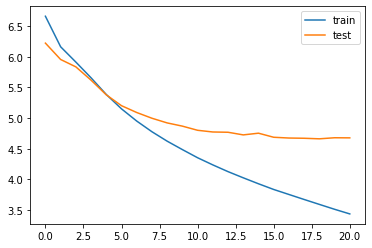

In [44]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

In [45]:
# 인퍼런스 모델 구현 시작

src_word_to_index = src_tokenizer.word_index # 원문 단어 집합에서 단어 -> 정수를 얻음
src_index_to_word = src_tokenizer.index_word # 원문 단어 집합에서 정수 -> 단어를 얻음
tar_word_to_index = tar_tokenizer.word_index # 요약 단어 집합에서 단어 -> 정수를 얻음
tar_index_to_word = tar_tokenizer.index_word # 요약 단어 집합에서 정수 -> 단어를 얻음

In [46]:
# 인코더 설계
encoder_model = Model(inputs=encoder_inputs, outputs=[encoder_outputs, state_h, state_c])

# 이전 시점의 상태들을 저장하는 텐서
decoder_state_input_h = Input(shape=(hidden_size,))
decoder_state_input_c = Input(shape=(hidden_size,))

dec_emb2 = dec_emb_layer(decoder_inputs)

# 문장의 다음 단어를 예측하기 위해서 초기 상태(initial_state)를 이전 시점의 상태로 사용. 이는 뒤의 함수 decode_sequence()에 구현
# 훈련 과정에서와 달리 LSTM의 리턴하는 은닉 상태와 셀 상태인 state_h와 state_c를 버리지 않음.
decoder_outputs2, state_h2, state_c2 = decoder_lstm(dec_emb2, initial_state=[decoder_state_input_h, decoder_state_input_c])

In [47]:
# 어텐션 함수
decoder_hidden_state_input = Input(shape=(text_max_len, hidden_size))
attn_out_inf = attn_layer([decoder_outputs2, decoder_hidden_state_input])
decoder_inf_concat = Concatenate(axis=-1, name='concat')([decoder_outputs2, attn_out_inf])

# 디코더의 출력층
decoder_outputs2 = decoder_softmax_layer(decoder_inf_concat) 

# 최종 디코더 모델
decoder_model = Model(
    [decoder_inputs] + [decoder_hidden_state_input,decoder_state_input_h, decoder_state_input_c],
    [decoder_outputs2] + [state_h2, state_c2])

In [48]:
def decode_sequence(input_seq):
    # 입력으로부터 인코더의 상태를 얻음
    e_out, e_h, e_c = encoder_model.predict(input_seq)

     # <SOS>에 해당하는 토큰 생성
    target_seq = np.zeros((1,1))
    target_seq[0, 0] = tar_word_to_index['sostoken']

    stop_condition = False
    decoded_sentence = ''
    while not stop_condition: # stop_condition이 True가 될 때까지 루프 반복

        output_tokens, h, c = decoder_model.predict([target_seq] + [e_out, e_h, e_c])
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_token = tar_index_to_word[sampled_token_index]

        if (sampled_token!='eostoken'):
            decoded_sentence += ' '+sampled_token

        #  <eos>에 도달하거나 최대 길이를 넘으면 중단.
        if (sampled_token == 'eostoken'  or len(decoded_sentence.split()) >= (headlines_max_len-1)):
            stop_condition = True

        # 길이가 1인 타겟 시퀀스를 업데이트
        target_seq = np.zeros((1,1))
        target_seq[0, 0] = sampled_token_index

        # 상태를 업데이트 합니다.
        e_h, e_c = h, c

    return decoded_sentence

In [49]:
# 원문의 정수 시퀀스를 텍스트 시퀀스로 변환
def seq2text(input_seq):
    temp=''
    for i in input_seq:
        if i!=0:
            temp = temp + src_index_to_word[i]+' '
    return temp

# 요약문의 정수 시퀀스를 텍스트 시퀀스로 변환
def seq2summary(input_seq):
    temp=''
    started = False
    for i in input_seq:
        if i >= 1:
            word = tar_index_to_word[i]
            if word == 'sostoken':
                started = True
            elif word == 'eostoken':
                break
            elif started:
                temp = temp + word + ' '
    return temp.strip() # 마지막 공백 제거

In [50]:
for i in range(50, 100):
    print("원문 :", seq2text(encoder_input_test[i]))
    print("실제 요약 :", seq2summary(decoder_input_test[i]))
    print("예측 요약 :", decode_sequence(encoder_input_test[i].reshape(1, text_max_len)))
    print("\n")

원문 : bennington wife rock band linkin park singer chester bennington took twitter share video singer hours suicide wrote depression face mood depression looked like us death video chester seen playing game family 
실제 요약 : video shows linkin park chester hrs before suicide
예측 요약 :  linkin jackson shares picture of her daughters


원문 : facebook owned photo sharing platform instagram started testing direct standalone app offers private messaging users user direct inbox disappear instagram app accessed new messaging app direct facebook third standalone messaging application whatsapp messenger 
실제 요약 : instagram tests standalone app for private messaging
예측 요약 :  facebook tests feature to let users in messenger


원문 : nawazuddin siddiqui said acts impress people adding would craft said take journey trying discover different characters however nawazuddin admitted dancing munna michael scary experience insecure dancing skills 
실제 요약 : act for myself and not to impress people nawazuddin
예측 요약 

In [51]:
# summa 라이브러리를 이용한 추출적 요약 시작

import os
from summa.summarizer import summarize

In [52]:
f = open("news.txt", 'r')
text = f.read()
f.close()

In [53]:
# 요약 대상 기사 원문

print(text[:1500])

UK creating ‘murder prediction’ tool to identify people most likely to kill
Exclusive: Algorithms allegedly being used to study data of thousands of people, in project critics say is ‘chilling and dystopian’

The UK government is developing a “murder prediction” programme which it hopes can use personal data of those known to the authorities to identify the people most likely to become killers.

Researchers are alleged to be using algorithms to analyse the information of thousands of people, including victims of crime, as they try to identify those at greatest risk of committing serious violent offences.

The scheme was originally called the “homicide prediction project”, but its name has been changed to “sharing data to improve risk assessment”. The Ministry of Justice hopes the project will help boost public safety but campaigners have called it “chilling and dystopian”.

The existence of the project was discovered by the pressure group Statewatch, and some of its workings uncovered 

In [54]:
# 요약 1 : Summary 모델로 요약

print('Summary:')
print(summarize(text, ratio=0.05))

Summary:
Statewatch says data from people not convicted of any criminal offence will be used as part of the project, including personal information about self-harm and details relating to domestic abuse.


In [55]:
# 요약 2 : Summary 모델로 요약

print('Summary:')
print(summarize(text, words=50))

Summary:
Statewatch says data from people not convicted of any criminal offence will be used as part of the project, including personal information about self-harm and details relating to domestic abuse.
The government says the project is at this stage for research only, but campaigners claim the data used would build bias into the predictions against minority-ethnic and poor people.


In [65]:
# 요약 3 : seq2seq으로 요약 : 실패

print('Summary:')
print(seq2summary(text))

Summary:


TypeError: '>=' not supported between instances of 'str' and 'int'

In [61]:
# 요약 4 : 직접 만든 인퍼런스 모델로 요약 : 실패

print('Summary:')
print(decode_sequence(text.reshape(1, text_max_len)))

Summary:


AttributeError: 'list' object has no attribute 'reshape'